# EFG Simulation Analysis

This notebook analyses a finite-element simulation of the electric field gradient (EFG) experienced by an antimony (Sb, $I = 7/2$) nucleus in a semiconductor device.

The simulation exports the local strain tensor $\varepsilon_{ab}$ and electric field $\mathbf{E}$ on a 3-D spatial grid. From these, we:

1. Compute the full EFG tensor $V_{ab}$ at every grid point using material coupling tensors.
2. Diagonalise $V_{ab}$ to find the principal axis system (PAS) and eigenvalues.
3. Build the quadrupole + Zeeman Hamiltonian at every grid point and extract the transition frequencies $f_{Q,1}$ and $f_{Q,2}$.
4. Visualise the spatial variation as 2-D slices, isosurfaces, and animated GIFs.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr

from psyduck.hamiltonians import quadrupole_hamiltonian_from_Vab, zeeman_hamiltonian
from psyduck.tensors import get_S_tensor, get_R_tensor, voigt_to_tensor, tensor_to_voigt

plt.style.use('default')

## EFG Tensor Computation

The electric field gradient (EFG) tensor $V_{ab}$ ($a, b \in \{x,y,z\}$) is a symmetric, traceless rank-2 tensor. It couples to the nuclear quadrupole moment and drives the quadrupole splitting of the spin levels.

In a strained semiconductor, $V_{ab}$ receives two contributions:

$$V_{ab} = \sum_{cd} S_{ab,cd}\, \varepsilon_{cd} \;+\; \sum_{c} R_{ab,c}\, E_c$$

### The $S$-tensor — strain–EFG coupling

$S_{ab,cd}$ maps the strain tensor $\varepsilon_{cd}$ to the EFG. In Voigt notation it becomes a $6\times 6$ matrix. For a cubic semiconductor (silicon), crystal symmetry constrains it to two independent components, $S_{11}$ and $S_{44}$:

$$\mathbf{S} = \begin{pmatrix} S_{11} & S_{12} & S_{12} & 0 & 0 & 0 \\ S_{12} & S_{11} & S_{12} & 0 & 0 & 0 \\ S_{12} & S_{12} & S_{11} & 0 & 0 & 0 \\ 0 & 0 & 0 & S_{44} & 0 & 0 \\ 0 & 0 & 0 & 0 & S_{44} & 0 \\ 0 & 0 & 0 & 0 & 0 & S_{44} \end{pmatrix}$$

where $S_{12} = -S_{11}/2$ is fixed by the tracelessness of $V_{ab}$, and $S_{11} = 2\times10^{22}$ V/m², $S_{44} = 5.9\times10^{22}$ V/m².

### The $R$-tensor — piezoelectric EFG coupling

$R_{ab,c}$ maps the electric field $E_c$ to the EFG. For a zinc-blende crystal ($T_d$ point group), only the off-diagonal component $R_{14}$ is non-zero:

$$V_{yz} = R_{14}\,E_x, \qquad V_{xz} = R_{14}\,E_y, \qquad V_{xy} = R_{14}\,E_z$$

with $R_{14} = 1.7\times10^{12}$ V/m². This term is particularly important near the oxide interface where large electric fields are present.

### Vectorised computation

Both tensors are applied simultaneously to all $N \approx 7\times10^6$ grid points by treating the data as matrices:

$$\mathbf{V}_\text{voigt} = \mathbf{S}\,\boldsymbol{\varepsilon}^T + \mathbf{R}\,\mathbf{E}^T \;\in\; \mathbb{R}^{6 \times N}$$

In [81]:
data_path = r'C:\Users\z5380600\UNSW\Antimony Venus - General\data\EFG_simulation_data/'
file_name = r'Thermal_Strain_Electric_Field_400Cto0_2K_Sb2_MV24_OJ42_reconstructed_w_h.txt'

ds = xr.load_dataset(data_path + file_name[:-4] + fr'analyzed_z.nc')

In [108]:
d = ds.isel(x=90, y=40, z=100) # middle

In [109]:
d

<xarray.Dataset> Size: 292B
Dimensions:        (component: 3, eigvec_idx: 3)
Coordinates:
  * component      (component) object 24B 'x' 'y' 'z'
  * eigvec_idx     (eigvec_idx) int32 12B 0 1 2
    y              float64 8B -0.04
    z              float64 8B 0.0
    x              float64 8B 0.0
Data variables: (12/19)
    pas_vectors    (component, eigvec_idx) float64 72B 0.9542 0.2231 ... 0.9798
    pas_eigenvals  (eigvec_idx) float64 24B 3.343e+18 1.951e+19 -2.286e+19
    strain_xx      float64 8B -0.001451
    strain_yy      float64 8B -0.0004871
    strain_zz      float64 8B -0.001392
    strain_yz      float64 8B 9.686e-06
    ...             ...
    EFG_zz         float64 8B -2.18e+19
    EFG_yz         float64 8B 5.475e+16
    EFG_xz         float64 8B -5.209e+18
    EFG_xy         float64 8B 3.613e+18
    fq_1           float64 8B 2.594e+04
    fq_2           float64 8B 4.231

In [110]:
strain_vector = np.array([d.strain_xx, d.strain_yy, d.strain_zz, d.strain_yz, d.strain_xz, d.strain_xy])
E_vector = np.array([d.E_x, d.E_y, d.E_z])
S_tensor = get_S_tensor()   # S11=2e22, S44=5.9e22 V/m
R_tensor = get_R_tensor()   # R14=1.7e12 V/m²
EFG_tensor_vec = (S_tensor@strain_vector.T + R_tensor@E_vector.T).T
EFG_tensors = voigt_to_tensor(EFG_tensor_vec)                   # (N, 3, 3)

In [111]:
quad_energies

array([-27270539.24173391, -19435937.91106384, -11622871.84376961,
        -3831320.45056809,   3938737.0261213 ,  11687321.53846977,
        19414454.26120512,  27120156.62133927])

In [112]:

# iterate over E_y
E_ys = np.linspace(d.E_y.values - 8e6, d.E_y.values + 8e6, 20)
thetas = np.linspace(0, np.pi, 40)

S_tensor = get_S_tensor()
R_tensor = get_R_tensor()

E_vectors = np.array([[d.E_x] * len(E_ys), E_ys, [d.E_z] * len(E_ys)])  # (3, len(E_ys))
S_term = S_tensor @ strain_vector                                          # (6,)
R_terms = R_tensor @ E_vectors                                             # (6, len(E_ys))

def _fq(EFG_voigts):
    """Compute fq_1 and fq_2 arrays of shape (len(thetas), len(E_ys)) from EFG voigt vectors."""
    EFG_tensors = voigt_to_tensor(EFG_voigts)
    H_quads = quadrupole_hamiltonian_from_Vab(I=7/2, V_ab=EFG_tensors, Q=-0.69e-28)
    H_totals = H_zs[:, np.newaxis] + H_quads[np.newaxis]
    energies = np.linalg.eigh(H_totals)[0]
    fq1 = np.mean(np.diff(np.diff(energies, axis=-1), axis=-1), axis=-1)
    fq2 = np.mean(np.diff(np.diff(np.diff(energies, axis=-1), axis=-1), axis=-1), axis=-1)
    return fq1, fq2

# Precompute H_z for all theta values  →  (len(thetas), 8, 8)
H_zs = np.array([zeeman_hamiltonian(I=7/2, B0=1.4, gamma=5.55e6, theta=t, phi=0).full()
                 for t in thetas])

# Total: strain + E field
fq_1, fq_2 = _fq((S_term[:, np.newaxis] + R_terms).T)

# Strain only (S_term is constant → tile to (len(E_ys), 6))
fq_1_strain, _ = _fq(np.tile(S_term, (len(E_ys), 1)))

# Electric field only
fq_1_E, _ = _fq(R_terms.T)


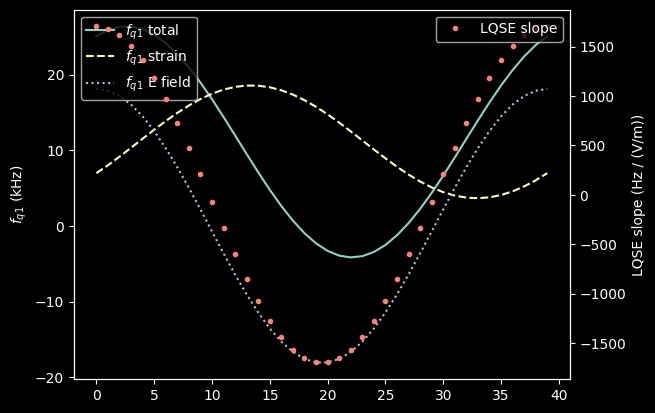

In [113]:

j_mid = fq_1.shape[1] // 2
lqse_slope = np.mean(np.diff(-fq_1, axis=1), axis=1)

fig, ax = plt.subplots(1, 1)
ax.plot(fq_1[:, j_mid] * 1e-3,        label=r'$f_{q1}$ total')
ax.plot(fq_1_strain[:, j_mid] * 1e-3, label=r'$f_{q1}$ strain', linestyle='--')
ax.plot(fq_1_E[:, j_mid] * 1e-3,      label=r'$f_{q1}$ E field', linestyle=':')
ax.set_ylabel(r'$f_{q1}$ (kHz)')
ax.legend(loc='upper left')

ax_ = ax.twinx()
ax_.plot(lqse_slope, '.', color='C3', label='LQSE slope')
ax_.set_ylabel('LQSE slope (Hz / (V/m))')
ax_.legend(loc='upper right')


## Spatial map of strain vs E-field contributions at $\theta = 0$

For a fixed depth slice ($y$ = const), compute $f_{q1}$ independently from strain and E-field contributions at every $(x, z)$ grid point, then show each as a fraction of the total.

In [121]:

STEP = 5  # spatial downsampling factor in x and z
ds_down = ds.isel(x=slice(None, None, STEP), z=slice(None, None, STEP))

H_z_0 = zeeman_hamiltonian(I=7/2, B0=1.4, gamma=5.55e6, theta=0, phi=0).full()

n_y = len(ds_down.y)

# Determine spatial shape from first slice
_ds0 = ds_down.isel(y=0)
_s0 = np.stack([_ds0.strain_xx.values, _ds0.strain_yy.values, _ds0.strain_zz.values,
                _ds0.strain_yz.values, _ds0.strain_xz.values, _ds0.strain_xy.values], axis=-1)
spatial_shape = _s0.shape[:2]  # (N_x_down, N_z_down)

fq1_total_all  = np.empty((n_y,) + spatial_shape)
fq1_strain_all = np.empty((n_y,) + spatial_shape)
fq1_E_all      = np.empty((n_y,) + spatial_shape)

def _fq1(EFG_voigts, shape):
    EFG_t = voigt_to_tensor(EFG_voigts)
    H_q = quadrupole_hamiltonian_from_Vab(I=7/2, V_ab=EFG_t, Q=-0.69e-28)
    energies = np.linalg.eigh(H_z_0[np.newaxis] + H_q)[0]
    return np.mean(np.diff(np.diff(energies, axis=-1), axis=-1), axis=-1).reshape(shape)

for y_idx in range(n_y):
    ds_y = ds_down.isel(y=y_idx)
    strain_flat = np.stack([
        ds_y.strain_xx.values, ds_y.strain_yy.values, ds_y.strain_zz.values,
        ds_y.strain_yz.values, ds_y.strain_xz.values, ds_y.strain_xy.values,
    ], axis=-1).reshape(-1, 6)
    E_flat = np.stack([
        ds_y.E_x.values, ds_y.E_y.values, ds_y.E_z.values,
    ], axis=-1).reshape(-1, 3)

    fq1_total_all[y_idx]  = _fq1((S_tensor @ strain_flat.T + R_tensor @ E_flat.T).T, spatial_shape)
    fq1_strain_all[y_idx] = _fq1((S_tensor @ strain_flat.T).T,                        spatial_shape)
    fq1_E_all[y_idx]      = _fq1((R_tensor @ E_flat.T).T,                             spatial_shape)

    if y_idx % 20 == 0:
        print(f"  {y_idx}/{n_y}", end='\r')

print(f"Done. Shape: {fq1_total_all.shape}")

strain_factor_all = fq1_strain_all / fq1_total_all
E_factor_all      = fq1_E_all      / fq1_total_all
_vabs = np.nanpercentile(np.abs([strain_factor_all, E_factor_all]), 98)

x_coords = ds_down.x.values
z_coords = ds_down.z.values
y_coords = ds_down.y.values


Done. Shape: (201, 37, 41)


In [122]:

import ipywidgets as widgets

def plot_contributions(y_idx):
    strain_factor = strain_factor_all[y_idx]
    E_factor      = E_factor_all[y_idx]
    y_val = float(y_coords[y_idx])

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(fr'$y = {y_val:.4f}$  (index {y_idx}),  $\theta = 0$')
    for ax, data, title in zip(
        axes,
        [strain_factor, E_factor],
        [r'Strain  ($f_{q1}^{\rm strain} / f_{q1}^{\rm total}$)',
         r'E-field  ($f_{q1}^{\rm E} / f_{q1}^{\rm total}$)'],
    ):
        im = ax.pcolormesh(z_coords, x_coords, data, cmap='RdBu_r', vmin=-_vabs, vmax=_vabs)
        fig.colorbar(im, ax=ax)
        ax.set_title(title)
        ax.set_xlabel('z')
        ax.set_ylabel('x')
    fig.tight_layout()
    plt.show()

widgets.interact(
    plot_contributions,
    y_idx=widgets.IntSlider(
        min=0, max=len(y_coords) - 1, step=1, value=len(y_coords) // 2,
        description='y index', layout=widgets.Layout(width='500px'),
    ),
)


interactive(children=(IntSlider(value=100, description='y index', layout=Layout(width='500px'), max=200), Outp…

<function __main__.plot_contributions(y_idx)>

## Phase of strain vs E-field contributions relative to LQSE angular dependence

For each spatial point $(x, z)$ at fixed $y$, sweep the B-field angle $\theta \in [0, \pi]$ and compute $f_{q1}(\theta)$ for the total, strain-only, and E-field-only Hamiltonians. The **relative phase** is the Pearson correlation of each contribution's $\theta$-curve against the total — $+1$ means perfectly in-phase, $-1$ means out-of-phase.

In [123]:

STEP_PH = 10   # coarser spatial downsampling (x, z) for theta sweep
N_THETA = 16   # number of B-field angles

ds_ph = ds.isel(x=slice(None, None, STEP_PH), z=slice(None, None, STEP_PH))
thetas_ph = np.linspace(0, np.pi, N_THETA)
H_zs_ph = np.array([zeeman_hamiltonian(I=7/2, B0=1.4, gamma=5.55e6, theta=t, phi=0).full()
                     for t in thetas_ph])  # (N_THETA, 8, 8)

n_y_ph = len(ds_ph.y)
_ds0_ph = ds_ph.isel(y=0)
_s0_ph = np.stack([_ds0_ph.strain_xx.values, _ds0_ph.strain_yy.values, _ds0_ph.strain_zz.values,
                   _ds0_ph.strain_yz.values, _ds0_ph.strain_xz.values, _ds0_ph.strain_xy.values], axis=-1)
spatial_shape_ph = _s0_ph.shape[:2]  # (N_x_down, N_z_down)

phase_strain_all = np.empty((n_y_ph,) + spatial_shape_ph)
phase_E_all      = np.empty((n_y_ph,) + spatial_shape_ph)

def _fq1_theta_sweep(H_quads):
    """H_quads: (N_spatial, 8, 8)  →  fq_1: (N_THETA, N_spatial)."""
    H_totals = H_zs_ph[:, np.newaxis] + H_quads[np.newaxis]           # (N_THETA, N_spatial, 8, 8)
    N_flat = H_totals.shape[0] * H_totals.shape[1]
    energies = np.linalg.eigh(H_totals.reshape(N_flat, 8, 8))[0]      # (N_flat, 8)
    energies = energies.reshape(N_THETA, -1, 8)                        # (N_THETA, N_spatial, 8)
    return np.mean(np.diff(np.diff(energies, axis=-1), axis=-1), axis=-1)  # (N_THETA, N_spatial)

def _pearson(f_test, f_ref):
    """Column-wise Pearson correlation along axis 0. f: (N_THETA, N_spatial)."""
    f_tc = f_test - f_test.mean(axis=0)
    f_rc = f_ref  - f_ref.mean(axis=0)
    numer = (f_tc * f_rc).sum(axis=0)
    denom = np.sqrt((f_tc**2).sum(axis=0) * (f_rc**2).sum(axis=0))
    return np.where(denom > 0, numer / denom, 0.0)

def _H_quads(EFG_voigts):
    return quadrupole_hamiltonian_from_Vab(I=7/2, V_ab=voigt_to_tensor(EFG_voigts), Q=-0.69e-28)

for y_idx in range(n_y_ph):
    ds_y = ds_ph.isel(y=y_idx)
    strain_flat = np.stack([
        ds_y.strain_xx.values, ds_y.strain_yy.values, ds_y.strain_zz.values,
        ds_y.strain_yz.values, ds_y.strain_xz.values, ds_y.strain_xy.values,
    ], axis=-1).reshape(-1, 6)
    E_flat = np.stack([
        ds_y.E_x.values, ds_y.E_y.values, ds_y.E_z.values,
    ], axis=-1).reshape(-1, 3)

    EFG_total  = (S_tensor @ strain_flat.T + R_tensor @ E_flat.T).T
    EFG_strain = (S_tensor @ strain_flat.T).T
    EFG_E      = (R_tensor @ E_flat.T).T

    fq1_total_th  = _fq1_theta_sweep(_H_quads(EFG_total))
    fq1_strain_th = _fq1_theta_sweep(_H_quads(EFG_strain))
    fq1_E_th      = _fq1_theta_sweep(_H_quads(EFG_E))

    phase_strain_all[y_idx] = _pearson(fq1_strain_th, fq1_total_th).reshape(spatial_shape_ph)
    phase_E_all[y_idx]      = _pearson(fq1_E_th,      fq1_total_th).reshape(spatial_shape_ph)

    if y_idx % 20 == 0:
        print(f"  {y_idx}/{n_y_ph}", end='\r')

print(f"Done. Shape: {phase_strain_all.shape}")

x_coords_ph = ds_ph.x.values
z_coords_ph = ds_ph.z.values
y_coords_ph = ds_ph.y.values


Done. Shape: (201, 19, 21)


In [124]:

def plot_phase(y_idx):
    y_val = float(y_coords_ph[y_idx])
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(fr'$y = {y_val:.4f}$  (index {y_idx})  —  relative phase vs LQSE $\theta$-dependence')
    for ax, data, title in zip(
        axes,
        [phase_strain_all[y_idx], phase_E_all[y_idx]],
        [r'Strain  (corr. with $f_{q1}^{\rm total}(\theta)$)',
         r'E-field  (corr. with $f_{q1}^{\rm total}(\theta)$)'],
    ):
        im = ax.pcolormesh(z_coords_ph, x_coords_ph, data, cmap='RdBu_r', vmin=-1, vmax=1)
        cb = fig.colorbar(im, ax=ax)
        cb.set_label('+1 in-phase, −1 out-of-phase')
        ax.set_title(title)
        ax.set_xlabel('z')
        ax.set_ylabel('x')
    fig.tight_layout()
    plt.show()

widgets.interact(
    plot_phase,
    y_idx=widgets.IntSlider(
        min=0, max=len(y_coords_ph) - 1, step=1, value=len(y_coords_ph) // 2,
        description='y index', layout=widgets.Layout(width='500px'),
    ),
)


interactive(children=(IntSlider(value=100, description='y index', layout=Layout(width='500px'), max=200), Outp…

<function __main__.plot_phase(y_idx)>